# PAXRAW Analysis and Visualizations

This notebook provides visualizations and analysis of the processed NHANES accelerometer data.
It requires the processed data from `01_pipeline.ipynb` to be available.

**Note:** For step-specific analysis (only available in 2005-2006 data), see `04_analyze_steps.ipynb`.

# Imports

In [1]:
import altair as alt
import numpy as np
import pandas as pd

from utils import CHAR_LOOKUP, flatten_columns, get_datadir, get_processed_datadir

In [2]:
pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 1000)
alt.data_transformers.enable("vegafusion")
alt.renderers.enable('png')

RendererRegistry.enable('png')

# Parameters

In [3]:
year: str = "2005-2006"

In [4]:
datadir = get_datadir(year)
processeddir = get_processed_datadir(year)
print(f"Raw data: {datadir}")
print(f"Processed data: {processeddir}")

Raw data: /Users/andyreagan/projects/2025/NHANES/data/raw/2005-2006
Processed data: /Users/andyreagan/projects/2025/NHANES/data/processed/2005-2006


In [5]:
# Intensity cuts and labels
int_cuts = [100, 760, 2020, 5999]
labels = ["Sedentary", "Low", "Light", "Moderate", "Vigorous"]

# Load processed data

In [6]:
# Load the reliable filtered data
paxraw_reliable = pd.read_parquet(
    processeddir / f"paxraw_{CHAR_LOOKUP[year].lower()}_met_worn_bouts_reliable.parquet"
)
paxraw_reliable.shape

(46186041, 29)

In [7]:
# Load the full data with bouts
paxraw = pd.read_parquet(
    processeddir / f"paxraw_{CHAR_LOOKUP[year].lower()}_met_worn_bouts.parquet"
)
paxraw.shape

(74874095, 20)

In [8]:
# Load person-day data
d_people_days = pd.read_parquet(
    processeddir / f"paxraw_{CHAR_LOOKUP[year].lower()}_people_days.parquet"
)
d_people_days.head()

,SEQN,PAXDAY,PAXINTEN_sum,PAXINTEN_last,max_intensity_sum,max_intensity_last,out_of_calibration_sum,out_of_calibration_last,unreliable_sum,unreliable_last,zero_steps_with_intensity_sum,zero_steps_with_intensity_last,too_many_steps_sum,too_many_steps_last,steps_filtered_500_sum,steps_filtered_500_last,steps_filtered_300_sum,steps_filtered_300_last,worn_sum,valid_day
0,31128.0,1.0,377456.0,0.0,0,0,0,0,0,0,0,0,0,0,9414,0,10819,0,1276.0,1
1,31128.0,2.0,308309.0,0.0,0,0,0,0,0,0,0,0,0,0,7643,0,9218,0,1009.0,1
2,31128.0,3.0,324734.0,0.0,0,0,0,0,0,0,0,0,0,0,7740,0,9067,0,1273.0,1
3,31128.0,4.0,229846.0,0.0,0,0,0,0,0,0,0,0,0,0,4419,0,5600,0,599.0,0
4,31128.0,5.0,304957.0,0.0,0,0,0,0,0,0,0,0,0,0,8001,0,9707,0,911.0,1


# Sample individual data

In [9]:
paxraw_sample = paxraw.loc[paxraw.SEQN == paxraw.SEQN.values[0], :].copy()
paxraw_sample.head()

,SEQN,PAXSTAT,PAXCAL,PAXDAY,PAXN,PAXHOUR,PAXMINUT,PAXINTEN,PAXSTEP,MET,worn,vigorous_bout,moderate_bout,light_bout,low_bout,sed_bout,no_bout,intensity,METh,activeMETh
0,31128.0,1.0,1.0,1.0,1.0,0.0,0.0,166.0,4.0,1.100000,1.0,0.0,0.0,0.0,0.0,0.0,1,1,0.018333,0.001667
1,31128.0,1.0,1.0,1.0,2.0,0.0,1.0,27.0,0.0,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.016667,0.000000
2,31128.0,1.0,1.0,1.0,3.0,0.0,2.0,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.016667,0.000000
3,31128.0,1.0,1.0,1.0,4.0,0.0,3.0,276.0,4.0,1.266667,1.0,0.0,0.0,0.0,0.0,0.0,1,1,0.021111,0.004444
4,31128.0,1.0,1.0,1.0,5.0,0.0,4.0,0.0,0.0,1.000000,1.0,0.0,0.0,0.0,0.0,0.0,1,0,0.016667,0.000000


# Intensity level visualizations

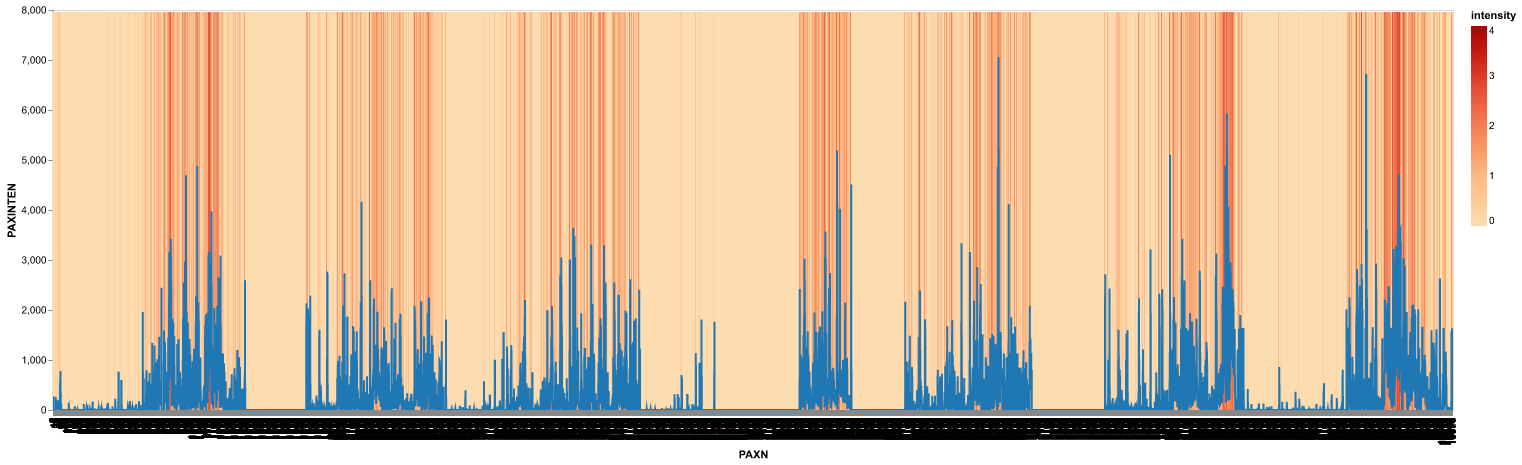

In [10]:
(
    alt.Chart(paxraw_sample)
    .mark_bar(width=1)
    .encode(
        x="PAXN:O",
        y=alt.value(400),
        y2=alt.value(2),
        color=alt.Color("intensity", scale=alt.Scale(scheme="orangered"))
    )
    + alt.Chart(paxraw_sample)
    .mark_line(color="#1f77b4", clip=True)
    .encode(x="PAXN:O", y=alt.Y("PAXINTEN", scale=alt.Scale(domain=[0, 8000])))
).properties(width=1400, height=400)

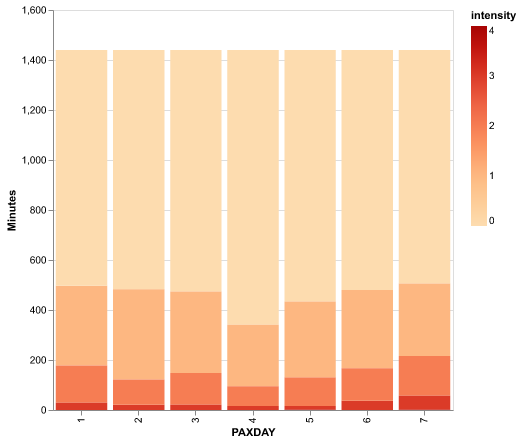

In [11]:
(
    alt.Chart(paxraw_sample)
    .mark_bar()
    .encode(
        x="PAXDAY:O",
        y=alt.Y("count()", title="Minutes"),
        color=alt.Color("intensity", scale=alt.Scale(scheme="orangered"))
    )
).properties(width=400, height=400)

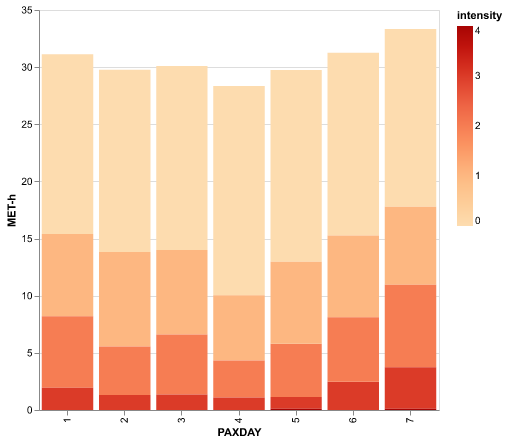

In [12]:
(
    alt.Chart(paxraw_sample)
    .mark_bar()
    .encode(
        x="PAXDAY:O",
        y=alt.Y("sum(METh)", title="MET-h"),
        color=alt.Color("intensity", scale=alt.Scale(scheme="orangered"))
    )
).properties(width=400, height=400)

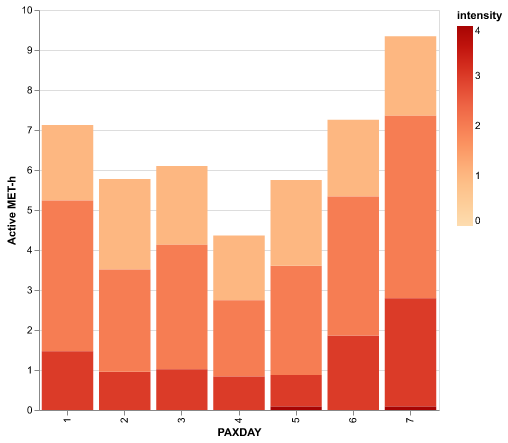

In [13]:
(
    alt.Chart(paxraw_sample)
    .mark_bar()
    .encode(
        x="PAXDAY:O",
        y=alt.Y("sum(activeMETh)", title="Active MET-h"),
        color=alt.Color("intensity", scale=alt.Scale(scheme="orangered"))
    )
).properties(width=400, height=400)

# MET-h thresholds analysis

## Group by intensity to sum MET-h levels

In [14]:
minutes_at_intensity = (
    paxraw_reliable.groupby(["SEQN", "intensity", "PAXDAY"])
    .agg({"activeMETh": "count"})
    .groupby(["SEQN", "intensity"])
    .agg({"activeMETh": "mean"})
    .groupby(["intensity"])
    .agg({"activeMETh": "mean"})
)
minutes_at_intensity

,activeMETh
intensity,
0,1066.611591
1,248.648890
2,91.780661
3,31.370411
4,5.691845


In [15]:
METh_at_intensity = (
    paxraw_reliable.groupby(["SEQN", "intensity", "PAXDAY"])
    .agg({"activeMETh": "sum"})
    .groupby(["SEQN", "intensity"])
    .agg({"activeMETh": "mean"})
    .groupby(["intensity"])
    .agg({"activeMETh": "mean"})
)
METh_at_intensity

,activeMETh
intensity,
0,0.000000
1,1.452151
2,2.365776
3,1.641446
4,0.517510


In [16]:
minutes_METh_stack = (
    pd.concat(
        [
            minutes_at_intensity.assign(metric="minutes"),
            METh_at_intensity.assign(metric="MET", activeMETh=lambda d: d.activeMETh * 60),
        ]
    )
    .reset_index()
    .merge(
        pd.DataFrame({"label": labels, "intensity": range(5)}),
        how="left",
        on="intensity",
    )
)
minutes_METh_stack

,intensity,activeMETh,metric,label
0,0,1066.611591,minutes,Sedentary
1,1,248.648890,minutes,Low
2,2,91.780661,minutes,Light
3,3,31.370411,minutes,Moderate
4,4,5.691845,minutes,Vigorous
5,0,0.000000,MET,Sedentary
6,1,87.129056,MET,Low
7,2,141.946539,MET,Light
8,3,98.486783,MET,Moderate
9,4,31.050574,MET,Vigorous


## MET Minutes vs Minutes by intensity level

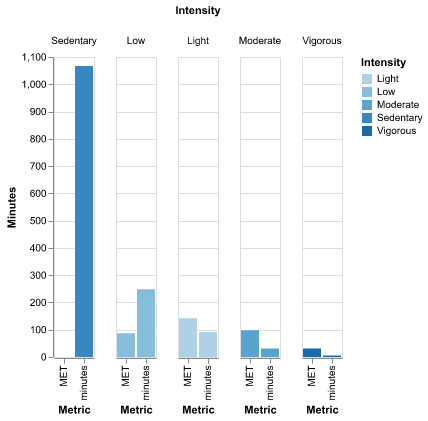

In [17]:
alt.Chart(minutes_METh_stack).mark_bar().encode(
    x=alt.X("metric:N", title="Metric"),
    y=alt.Y("activeMETh:Q", title="Minutes"),
    color=alt.Color("label:O", title="Intensity"),
    column=alt.Column(
        "label:O", title="Intensity", sort=alt.SortField("intensity", order="ascending")
    ),
)

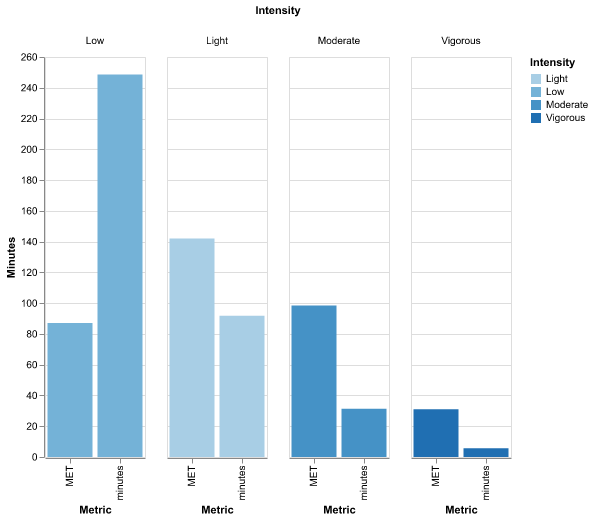

In [18]:
# Skip sedentary - no METs
alt.Chart(minutes_METh_stack.loc[minutes_METh_stack.intensity > 0, :]).mark_bar().encode(
    x=alt.X("metric:N", title="Metric"),
    y=alt.Y("activeMETh:Q", title="Minutes"),
    color=alt.Color("label:O", title="Intensity"),
    column=alt.Column(
        "label:O", title="Intensity", sort=alt.SortField("intensity", order="ascending")
    ),
).properties(width=100, height=400)

## Distribution of weekly METh

In [19]:
METh = (
    paxraw_reliable.groupby(["SEQN", "intensity", "PAXDAY"])
    .agg({"activeMETh": "sum"})
    .groupby(["SEQN", "intensity"])
    .agg({"activeMETh": "mean"})
    .groupby(["SEQN"])
    .agg({"activeMETh": "sum"})
).assign(weeklyMETh=lambda d: d.activeMETh * 7)
METh

,activeMETh,weeklyMETh
SEQN,,
31128.0,6.948343,48.638399
31129.0,4.943186,34.602302
31131.0,4.691044,32.837305
31132.0,8.396376,58.774635
31133.0,3.807062,26.649437
...,...,...
41468.0,2.945727,20.620088
41471.0,8.431049,59.017346
41472.0,5.776056,40.432393


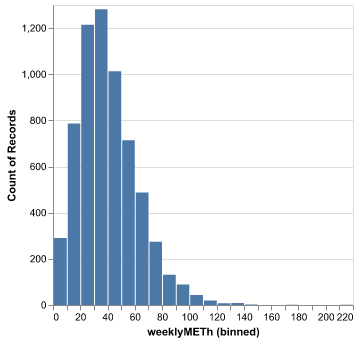

In [20]:
alt.Chart(METh).mark_bar().encode(
    alt.X("weeklyMETh:Q", bin=alt.BinParams(maxbins=35)),
    y="count()",
)

## METh thresholds and utilization

In [21]:
cut, cuts = pd.qcut(METh.weeklyMETh, 10, retbins=True)

utilization = pd.DataFrame(
    {
        "target": np.linspace(cuts[1], cuts[-2], num=50),
        "Total Utilization": [
            np.minimum(METh.weeklyMETh.values / x, 1).mean()
            for x in np.linspace(cuts[1], cuts[-2], num=50)
        ],
        "Max Rewards": [
            (METh.weeklyMETh.values / x >= 1).sum() / METh.shape[0]
            for x in np.linspace(cuts[1], cuts[-2], num=50)
        ],
    }
)
utilization.head()

,target,Total Utilization,Max Rewards
0,15.063555,0.964435,0.899921
1,16.155450,0.959692,0.889395
2,17.247345,0.954807,0.874941
3,18.339240,0.949546,0.858445
4,19.431135,0.943926,0.841005


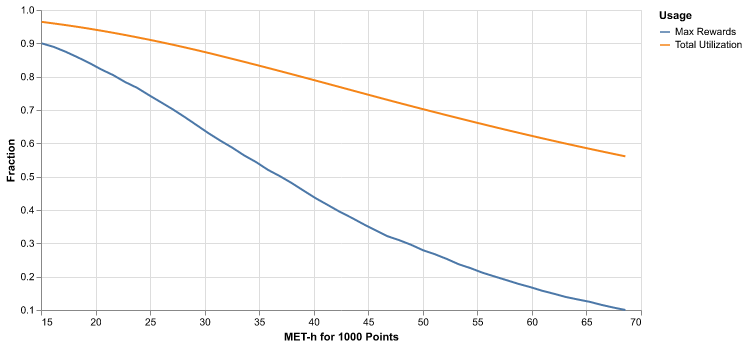

In [22]:
alt.Chart(utilization).mark_line().transform_fold(
    fold=["Total Utilization", "Max Rewards"], as_=["variable", "value"]
).encode(
    alt.X("target:Q", title="MET-h for 1000 Points"),
    alt.Y("value:Q", title="Fraction", scale=alt.Scale(zero=False)),
    alt.Color("variable:N", title="Usage"),
).properties(
    width=600
)

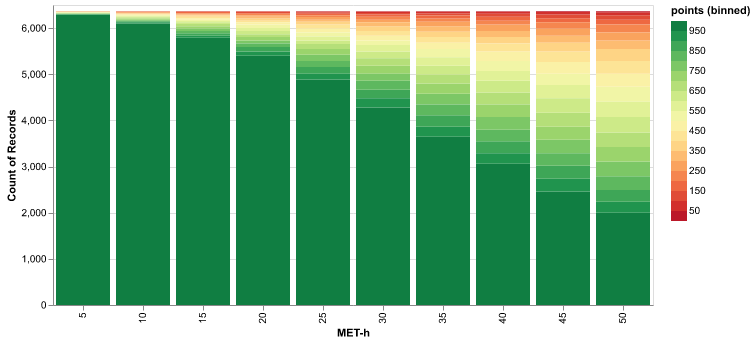

In [23]:
alt.Chart(
    pd.concat(
        [
            pd.DataFrame({"points": np.minimum(METh.weeklyMETh.values / x, 1) * 1000, "MET-h": x})
            for x in np.arange(5, 55, 5)
        ]
    )
).mark_bar().encode(
    alt.Color(
        "points:Q",
        bin=alt.BinParams(maxbins=20),
        scale=alt.Scale(scheme="redyellowgreen"),
    ),
    alt.Y("count()"),
    alt.X("MET-h:O"),
).properties(
    width=600
)

## Points by intensity for different amounts of points earned

In [24]:
all_intensities = pd.DataFrame(
    {
        "SEQN": np.repeat(pd.unique(paxraw_reliable.SEQN.values), 5),
        "intensity": np.tile(np.arange(5), pd.unique(paxraw_reliable.SEQN.values).shape[0]),
    }
)
all_intensities.head(11)

,SEQN,intensity
0,31128.0,0
1,31128.0,1
2,31128.0,2
3,31128.0,3
4,31128.0,4
5,31129.0,0
6,31129.0,1
7,31129.0,2
8,31129.0,3
9,31129.0,4


In [25]:
points_by_intensity = (
    paxraw_reliable.groupby(["SEQN", "intensity", "PAXDAY"], dropna=False)
    .agg({"activeMETh": "sum", "worn": "sum"})
    .groupby(["SEQN", "intensity"], dropna=False)
    .agg({"activeMETh": "mean", "worn": "mean"})
    .merge(all_intensities, how="outer", on=list(all_intensities.columns))
    .fillna(0)
    .assign(weeklyMETh=lambda d: d.activeMETh * 7, points=lambda d: d.weeklyMETh / 25 * 1000)
    .rename(columns={"worn": "dailyMinutes"})
    .reset_index()
)
points_by_intensity.head()

,index,SEQN,intensity,activeMETh,dailyMinutes,weeklyMETh,points
0,0,31128.0,0,0.000000,661.166667,0.000000,0.000000
1,1,31128.0,1,2.028245,318.666667,14.197715,567.908586
2,2,31128.0,2,3.367348,130.166667,23.571435,942.857407
3,3,31128.0,3,1.467198,29.833333,10.270383,410.815322
4,4,31128.0,4,0.085552,1.000000,0.598866,23.954649


In [26]:
points_by_person = (
    points_by_intensity.groupby("SEQN")
    .agg({"points": "sum"})
    .assign(
        points_capped=lambda d: np.minimum(d.points, 1000),
        point_bin=lambda d: pd.cut(d.points_capped, np.arange(11) * 100, right=True),
    )
)
points_by_person

,points,points_capped,point_bin
SEQN,,,
31128.0,1945.535964,1000.0000,"(900, 1000]"
31129.0,1384.092098,1000.0000,"(900, 1000]"
31131.0,1313.492211,1000.0000,"(900, 1000]"
31132.0,2350.985381,1000.0000,"(900, 1000]"
31133.0,1065.977470,1000.0000,"(900, 1000]"
...,...,...,...
41468.0,824.803500,824.8035,"(800, 900]"
41471.0,2360.693838,1000.0000,"(900, 1000]"
41472.0,1617.295733,1000.0000,"(900, 1000]"


In [27]:
point_thresholds_by_intensity = (
    points_by_intensity.merge(points_by_person, how="left", on="SEQN")
    .assign(
        points_relative=lambda d: d.points_x / d.points_y,
        dailyMinutesCapped=lambda d: d.dailyMinutes * d.points_capped / d.points_y,
    )
    .groupby(["point_bin", "intensity"], dropna=False, observed=True)
    .agg(
        {
            "points_relative": "mean",
            "points_capped": "mean",
            "dailyMinutesCapped": "mean",
        }
    )
    .assign(
        points=lambda d: d.points_relative * d.points_capped,
    )
    .reset_index()
    .assign(point_bin=lambda d: d.point_bin.astype("str"))
    .merge(pd.DataFrame({"label": labels, "intensity": np.arange(5)}), how="left", on="intensity")
)
point_thresholds_by_intensity

,point_bin,intensity,points_relative,points_capped,dailyMinutesCapped,points,label
0,"(0, 100]",0,0.000000,69.859540,727.050595,0.000000,Sedentary
1,"(0, 100]",1,0.514361,69.859540,51.444643,35.933012,Low
2,"(0, 100]",2,0.300741,69.859540,2.653929,21.009639,Light
3,"(0, 100]",3,0.184898,69.859540,0.994167,12.916889,Moderate
4,"(0, 100]",4,0.000000,69.859540,0.000000,0.000000,Vigorous
5,"(100, 200]",0,0.000000,151.907626,683.900794,0.000000,Sedentary
6,"(100, 200]",1,0.622829,151.907626,101.123982,94.612481,Low
7,"(100, 200]",2,0.241889,151.907626,5.160594,36.744810,Light
8,"(100, 200]",3,0.135282,151.907626,1.480538,20.550335,Moderate
9,"(100, 200]",4,0.000000,151.907626,0.000000,0.000000,Vigorous


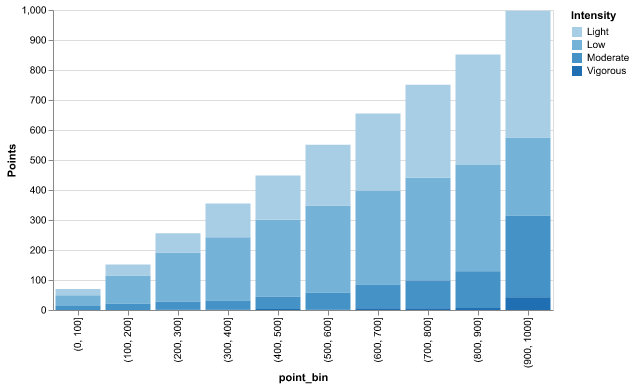

In [28]:
alt.Chart(
    point_thresholds_by_intensity.loc[point_thresholds_by_intensity.intensity > 0, :]
).mark_bar().encode(
    alt.X("point_bin:O"),
    alt.Y("points:Q", title="Points"),
    alt.Color("label:O", title="Intensity", sort=alt.SortField("label", order="ascending")),
).properties(
    width=500
)

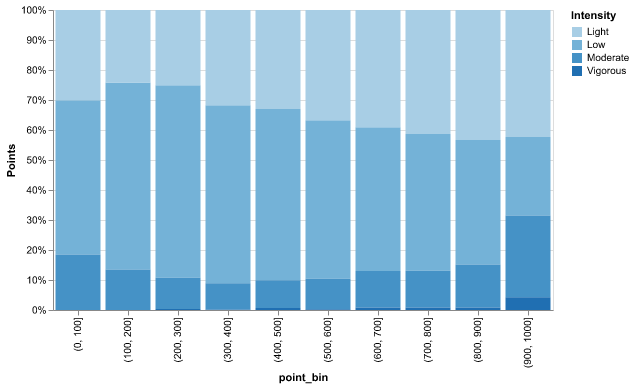

In [29]:
# Stacked bar chart
alt.Chart(
    point_thresholds_by_intensity.loc[point_thresholds_by_intensity.intensity > 0, :]
).mark_bar().encode(
    alt.X("point_bin:O"),
    alt.Y("points:Q", title="Points", stack="normalize"),
    alt.Color("label:O", title="Intensity", sort=alt.SortField("label", order="ascending")),
).properties(
    width=500
)

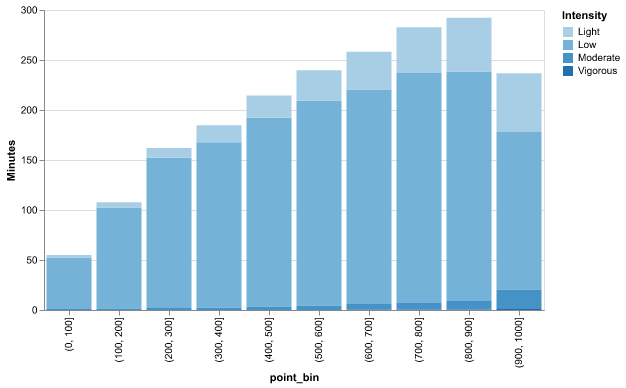

In [30]:
# Daily times in zones
alt.Chart(
    point_thresholds_by_intensity.loc[point_thresholds_by_intensity.intensity > 0, :]
).mark_bar().encode(
    alt.X("point_bin:O"),
    alt.Y("dailyMinutesCapped:Q", title="Minutes"),
    alt.Detail("label:O", title="Intensity"),
    alt.Color("label:O", title="Intensity", sort=alt.SortField("label", order="ascending")),
    tooltip=["label", "dailyMinutesCapped", "point_bin", "points"],
).properties(
    width=500
)

In [31]:
# Table view
point_thresholds_by_intensity.loc[point_thresholds_by_intensity.intensity > 0, :].pivot(
    index="point_bin", columns="label", values="dailyMinutesCapped"
).assign(Moderate_and_Vigorous=lambda d: d.Moderate + d.Vigorous * 2).rename(
    columns={"Moderate_and_Vigorous": "Moderate and Vigorous"}
).loc[
    :, ["Low", "Light", "Moderate and Vigorous"]
].astype(
    "int"
)

label,Low,Light,Moderate and Vigorous
point_bin,,,
"(0, 100]",51,2,0
"(100, 200]",101,5,1
"(200, 300]",150,9,2
"(300, 400]",165,16,2
"(400, 500]",189,22,3
"(500, 600]",205,30,4
"(600, 700]",214,37,6
"(700, 800]",230,45,7
"(800, 900]",229,53,9


# Daily intensity aggregation

In [32]:
by_day = (
    paxraw.groupby(["SEQN", "PAXDAY"])
    .agg({"PAXINTEN": ["sum", "mean", "max"]})
    .reset_index()
)
by_day.columns = flatten_columns(by_day.columns)
by_day.head()

,SEQN,PAXDAY,PAXINTEN_sum,PAXINTEN_mean,PAXINTEN_max
0,31128.0,1.0,377456.0,262.122222,4873.0
1,31128.0,2.0,308309.0,214.103472,4166.0
2,31128.0,3.0,324734.0,225.509722,3644.0
3,31128.0,4.0,229846.0,159.615278,5190.0
4,31128.0,5.0,304957.0,211.775694,7058.0


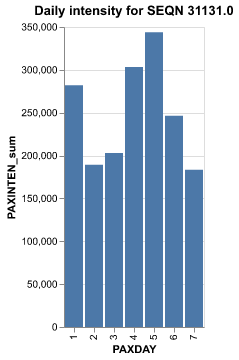

In [33]:
# Daily intensity for one person
id = 2
alt.Chart(by_day.loc[by_day.SEQN == by_day.SEQN.unique()[id], :]).mark_bar().encode(
    x="PAXDAY:O", y="PAXINTEN_sum"
).properties(title=f"Daily intensity for SEQN {by_day.SEQN.unique()[id]}")

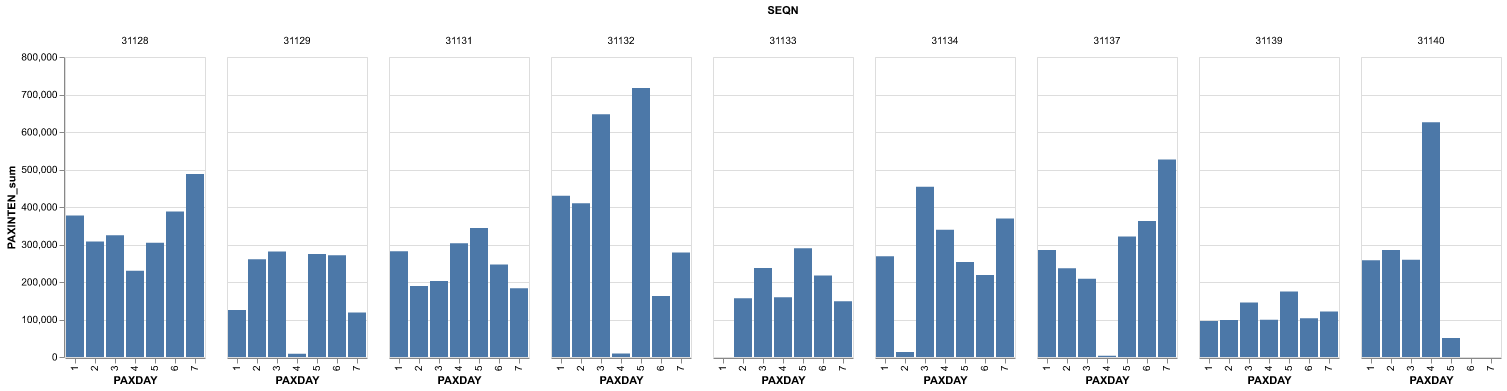

In [34]:
# Daily intensity for multiple people
alt.Chart(by_day.loc[by_day.SEQN.isin(by_day.SEQN.unique()[:9]), :]).mark_bar().encode(
    x="PAXDAY:O", y="PAXINTEN_sum", column="SEQN:N"
)

# Individual intensity timeline

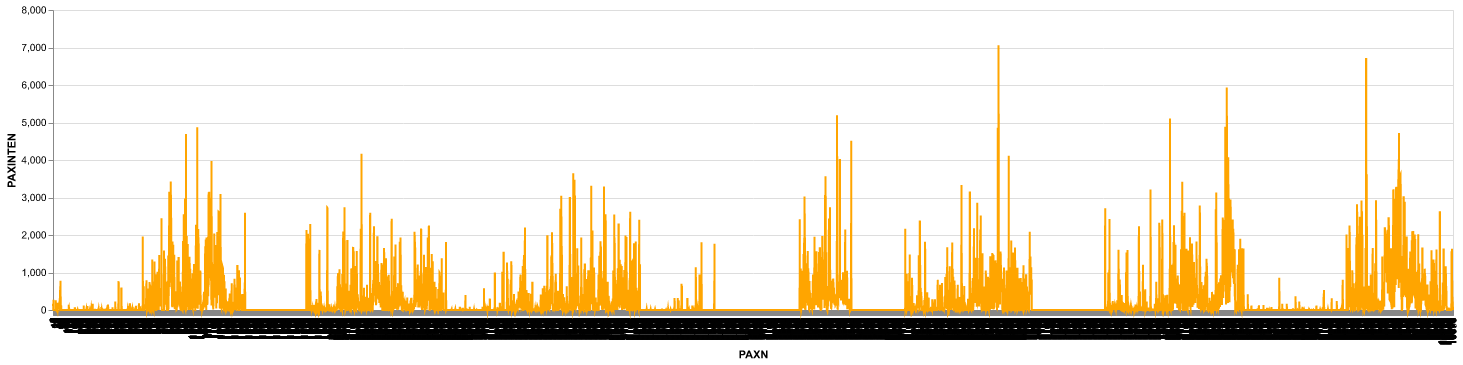

In [35]:
alt.Chart(paxraw.loc[paxraw.SEQN == by_day.SEQN.unique()[0], :]).mark_line(color="orange").encode(
    x="PAXN:O", y="PAXINTEN"
).properties(width=1400)

# Person-level activity summary

In [36]:
person_active_counts = d_people_days.loc[
    :, ["SEQN", "worn_sum", "PAXINTEN_sum", "valid_day"]
].copy()
person_active_counts.columns = ["SEQN", "worn_minutes", "activity_counts", "valid_day"]
person_active_counts.head()

,SEQN,worn_minutes,activity_counts,valid_day
0,31128.0,1276.0,377456.0,1
1,31128.0,1009.0,308309.0,1
2,31128.0,1273.0,324734.0,1
3,31128.0,599.0,229846.0,0
4,31128.0,911.0,304957.0,1


In [37]:
person_active_counts_summary = (
    person_active_counts.loc[person_active_counts.valid_day == 1, :]
    .groupby(["SEQN"])
    .agg({"worn_minutes": "mean", "activity_counts": "mean", "valid_day": "count"})
)
person_active_counts_summary.columns = [
    "daily_worn_minutes_mean",
    "daily_activity_count_sum_mean",
    "n_valid_days",
]
person_active_counts_summary.head()

,daily_worn_minutes_mean,daily_activity_count_sum_mean,n_valid_days
SEQN,,,
31128.0,1140.166667,365314.000000,6
31129.0,923.500000,271898.250000,4
31131.0,897.500000,261294.333333,6
31132.0,898.200000,473383.400000,5
31133.0,881.200000,212055.200000,5


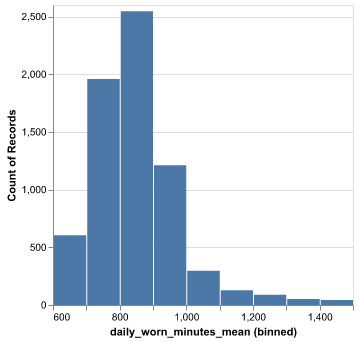

In [38]:
alt.Chart(person_active_counts_summary).mark_bar().encode(
    alt.X("daily_worn_minutes_mean:Q", bin=True),
    y="count()",
)

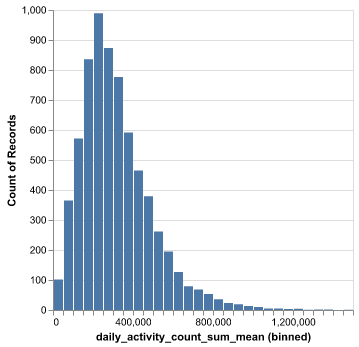

In [39]:
alt.Chart(person_active_counts_summary).mark_bar(clip=True).encode(
    alt.X(
        "daily_activity_count_sum_mean:Q",
        scale=alt.Scale(domain=[0, 1500000]),
        bin=alt.Bin(maxbins=1000),
    ),
    y="count()",
)

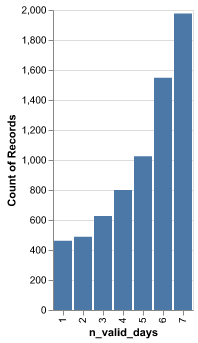

In [40]:
alt.Chart(person_active_counts_summary).mark_bar().encode(
    alt.X("n_valid_days:O"),
    y="count()",
)

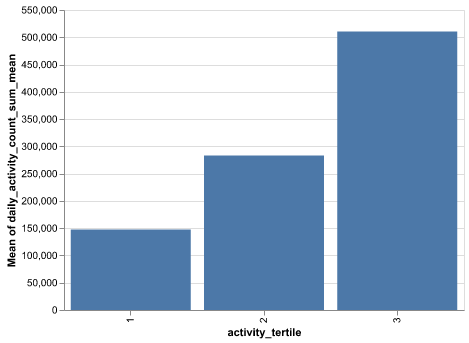

In [41]:
# Clear outliers and compute tertiles
person_active_counts_summary_filtered = person_active_counts_summary.loc[
    person_active_counts_summary.daily_activity_count_sum_mean < 1500000, :
].copy()

cuts = 3
person_active_counts_summary_filtered["activity_tertile"] = pd.qcut(
    person_active_counts_summary_filtered.daily_activity_count_sum_mean,
    q=cuts,
    labels=range(1, cuts + 1),
)

alt.Chart(person_active_counts_summary_filtered).mark_bar(clip=True).encode(
    alt.X("activity_tertile:O"),
    y="mean(daily_activity_count_sum_mean)",
).properties(width=400)